# 4. Rispondere alle domande
Trasforma le seguenti richiesti in formule per estrarre infromazioni dal dataframe
- Mostrami le vendite maggiori di 10

- Mostrami i dati del 2018

- Mostrami le vendite maggiori di 13 e l'anno è il 2018

- Mostrami tutto TRANNE i casi in cui le vendite sono maggiori di 13 e l'anno è il 2018

- Mostrami i dati dove le vendite divise per 3 sono maggiori di 3

- Mostrami i dipendenti i cui nomi sono alfabeticamente dopo la J



In [20]:
import pandas as pd

sales = pd.DataFrame(
    data={
        "employee": [
            "Katrina",
            "Guanyu",
            "Jan",
            "Roman",
            "Jacqueline",
            "Paola",
            "Esperanza",
            "Alaina",
            "Egweyn",
        ],
        "sales": [14, 17, 6, 12, 8, 3, 7, 15, 5],
        "year": [2018, 2019, 2020, 2018, 2020, 2019, 2019, 2020, 2020],
    }
)
sales

#Utilizzo .query per esprimere tutte le operazioni in un linguaggio più simile a python
sales_gt_10 = sales.query("sales > 10")
print(sales_gt_10)

sales_2018_data = sales.query("year == 2018")
print(sales_2018_data)

sales_gt_13_during_2018 = sales.query("year == 2018 and sales > 13")
print(sales_gt_13_during_2018)

all_sales_except_gt_13_and_in_2018 = sales.query("year != 2018 and sales < 14")
print(all_sales_except_gt_13_and_in_2018)

divided_by_3_and_gt_3 = sales.query("(sales / 3) > 3")
print(divided_by_3_and_gt_3)

#Partire da dopo la J vuol dire partire dalla K. fare ciò evita i casi in cui la somma dei valori ASCII 
#non soddisfi la richiesta ( ovvero che sia maggiore di J ). 
names_from_k = sales.query('employee >= "K"').sort_values(by="employee")
print(names_from_k)

  employee  sales  year
0  Katrina     14  2018
1   Guanyu     17  2019
3    Roman     12  2018
7   Alaina     15  2020
  employee  sales  year
0  Katrina     14  2018
3    Roman     12  2018
  employee  sales  year
0  Katrina     14  2018
     employee  sales  year
2         Jan      6  2020
4  Jacqueline      8  2020
5       Paola      3  2019
6   Esperanza      7  2019
8      Egweyn      5  2020
  employee  sales  year
0  Katrina     14  2018
1   Guanyu     17  2019
3    Roman     12  2018
7   Alaina     15  2020


# 5. Analisi di un dataset di video giochi
1. Quanti videogiochi sono stati pubblicati
2. Quali sono i generi più popolari? Mostralo con un bar plot
3. Plotta l'evoluzione del numero di giochi pubblicati nel tempo
4. Prova a riprodurre questo plot 

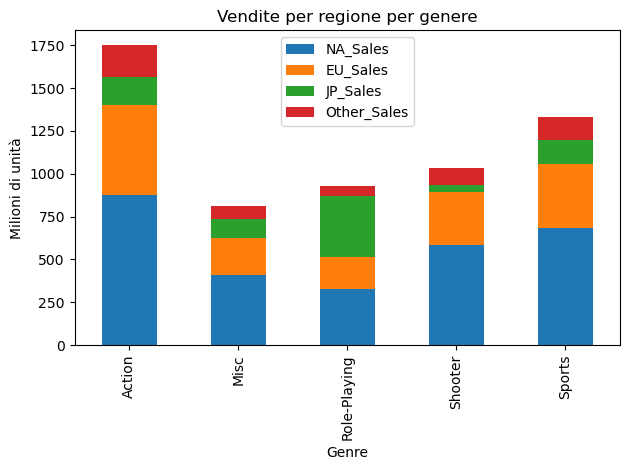


16598
11493
           Genre  Count
0         Action   3316
1         Sports   2346
2           Misc   1739
3   Role-Playing   1488
4        Shooter   1310
5      Adventure   1286
6         Racing   1249
7       Platform    886
8     Simulation    867
9       Fighting    848
10      Strategy    681
11        Puzzle    582


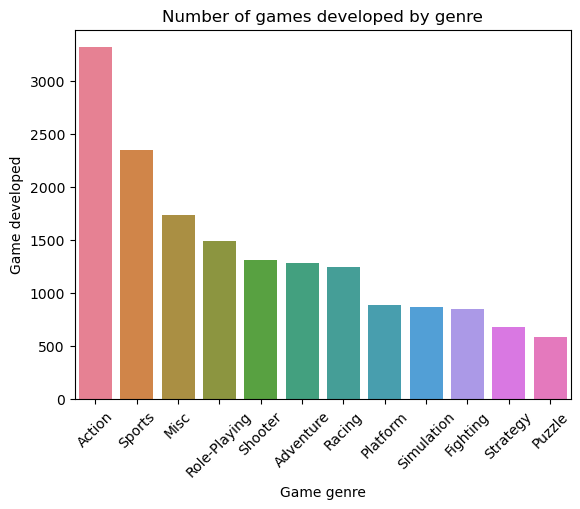

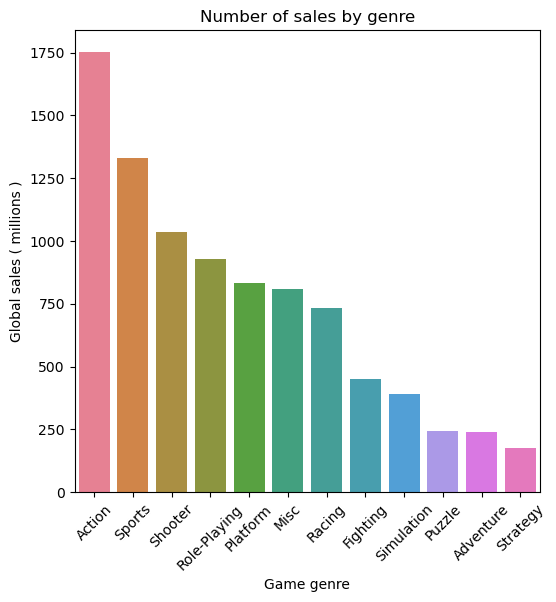

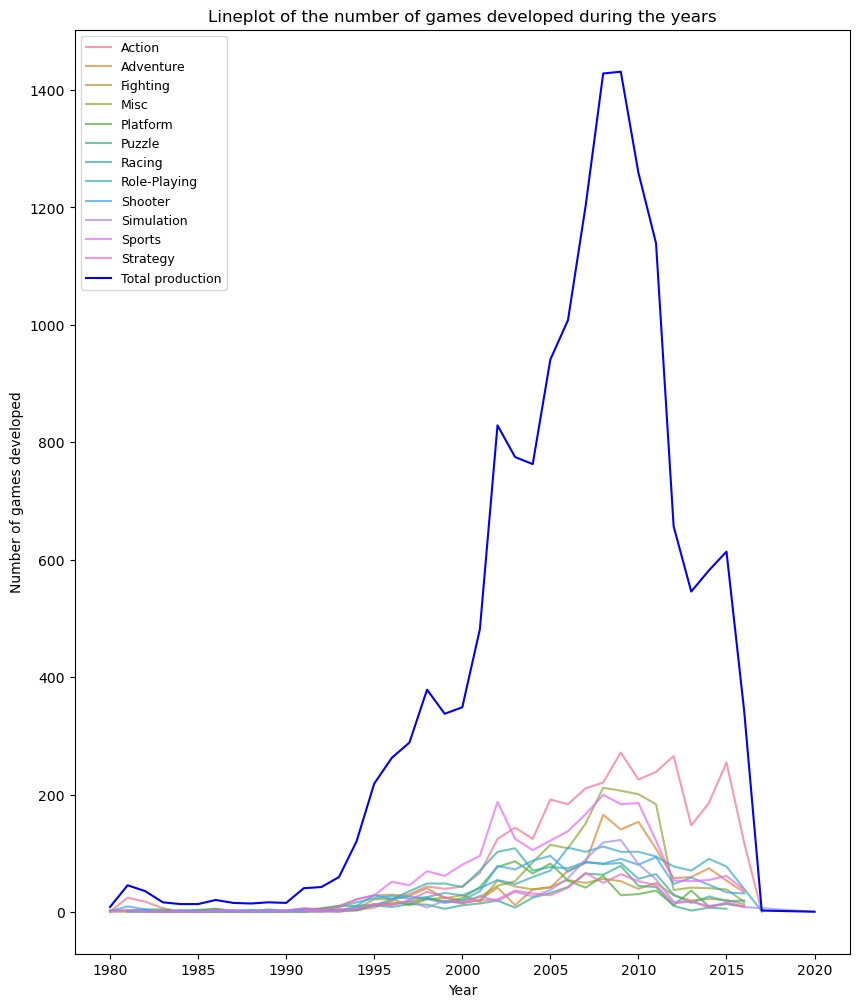

<Axes: xlabel='Genre'>

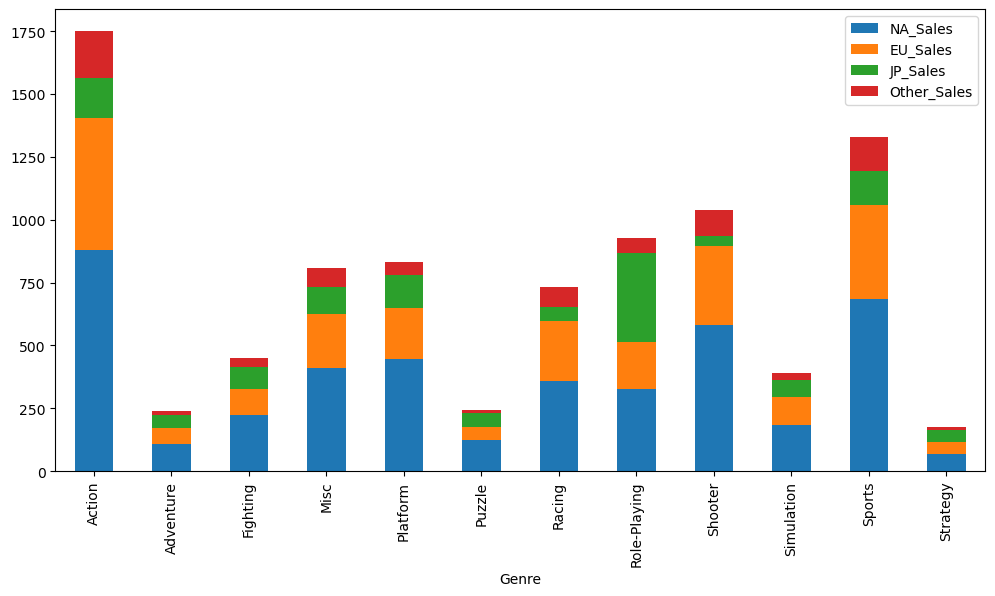

In [122]:
# Import dei pacchetti
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Caricamento del dataset
url = 'https://zenodo.org/record/5898311/files/vgsales.csv'
df = pd.read_csv(url)
df.head()

#In caso la domanda chieda il numero di titoli comprendenti anche se pubblicati su varie piattaforme 
print(len(df))

#Nel caso l'analisi richieda il singolo titolo e non il tipo di pubblicazione ( la piattaforma )
print(df["Name"].nunique())

#Ordino i giochi per gruppi e conto quanti gruppi ci sono, li riordino e poi trasformo la series in un dataframe
#Con una colonna di nome genere e una di nome Count per utilizzarla nel grafico
genre_count_per_type = df.groupby("Genre")["Genre"].count().sort_values(ascending=False).reset_index(name="Count")
print(genre_count_per_type)

#Si possono seguire due strade per quanto riguarda la popolarità. Quanti giochi della stessa categoria sono
#stati prodotti oppure quanti giochi della stessa categoria sono stati venduti. 

#Nel barplot sottostante sono rappresentati i giochi per numero di pubblicazioni
sns.barplot(data=genre_count_per_type, x="Genre", y="Count", hue="Genre")
plt.xticks(rotation=45)
plt.title("Number of games developed by genre")
plt.xlabel("Game genre")
plt.ylabel("Game developed")
plt.show()

#Nel barplot sottostante sono rappresentati i giochi per numero di vendite
df_sales_ordered = df.groupby("Genre")["Global_Sales"].sum().sort_values(ascending=False).reset_index()
plt.figure(figsize=(6,6))
sns.barplot(data=df_sales_ordered, x="Genre", y="Global_Sales", hue="Genre", errorbar=None)
plt.xticks(rotation=45)
plt.title("Number of sales by genre")
plt.xlabel("Game genre")
plt.ylabel("Global sales ( millions )")
plt.show()

#Creo due nuovi dataframe per il prossimo grafico. Uno è la somma di quanti giochi sono stati rilasciati
#durante un anno e l'altro rappresenta una divisione per genere di quanti giochi sono stati rilasciati negli anni
year_count = df.groupby("Year")["Year"].count().reset_index(name="Count")
year_count_per_genre = df.groupby(["Genre","Year"])["Genre"].count().reset_index(name="Count")

#Creo un lineplot in cui year_count rappresenta la totalità dei giochi rilasciati mentre year_count_per_genre
#rappresenta come i vari giochi sono usciti negli anni. Alzo la trasparenza di questi ultimi con alpha per 
#rendere il grafico più leggibile
plt.figure(figsize=(10,12))
sns.lineplot(data=year_count_per_genre, x="Year", y="Count", hue="Genre", alpha=0.7)
sns.lineplot(data=year_count, x="Year", y="Count", color="blue", label="Total production")
plt.legend(fontsize=9, loc="upper left")
plt.title("Lineplot of the number of games developed during the years")
plt.ylabel("Number of games developed")
plt.show()

#Divido il dataframe in genere e somma delle vendite per genere per regione. Sfrutto matplotlib per
#creare un grafico stacked. Notabene, questo grafico è composto da un df in cui gli indici sono i valori
#presenti sull'asse x, ovvero i generi. 
df_divided = df.groupby("Genre")[["NA_Sales","EU_Sales","JP_Sales","Other_Sales"]].sum()
df_divided.plot(kind="bar", stacked=True, figsize=(12, 6))